In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('UpdatedResumeDataset.csv')

In [3]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [4]:
df.shape

(962, 2)

In [5]:
df['Category'].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64

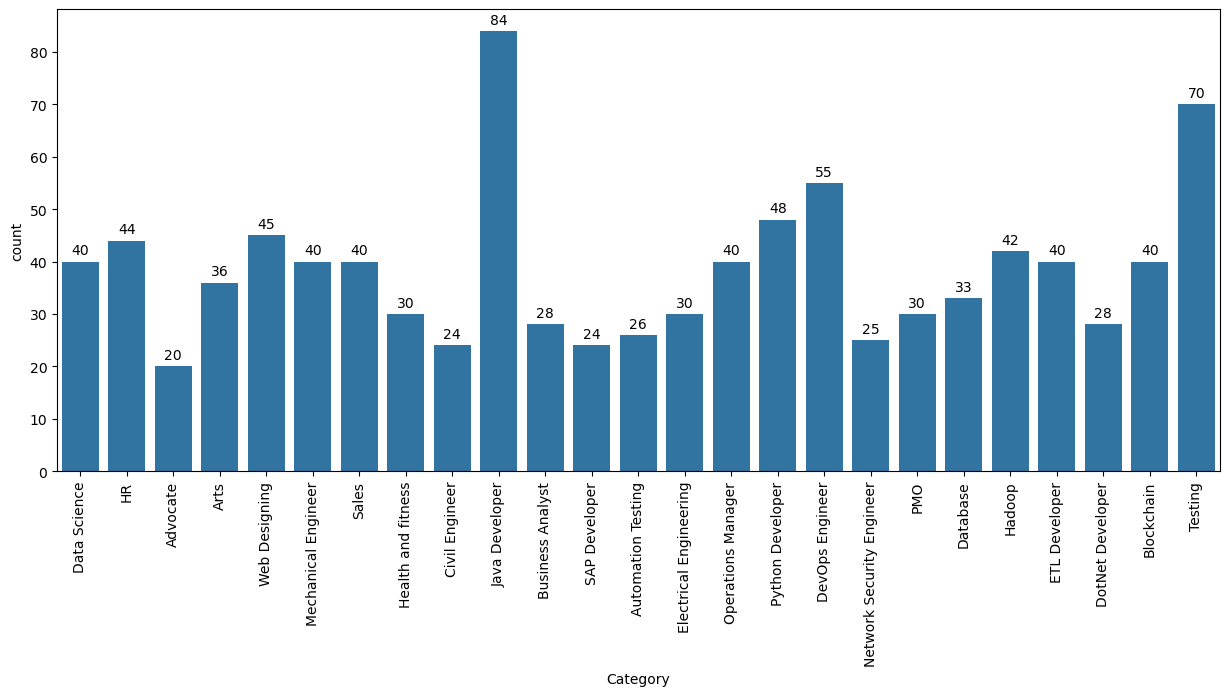

In [6]:
plt.figure(figsize=(15,6))
ax=sns.countplot(data= df,x='Category')
ax.bar_label(ax.containers[0], padding=3)
plt.xticks(rotation=90)
plt.show()

In [7]:
df['Category'][0]

'Data Science'

In [8]:
df['Resume'][90]

'Skills: Natural Languages: Proficient in English, Hindi and Marathi. Computer skills: Proficient with MS-Office, Internet operation.Education Details \r\nJanuary 2015 to January 2018 LLB Law Mumbai, Maharashtra Mumbai university\r\nJanuary 2015 B.M.M  Mumbai, Maharashtra S.K.Somaiya College, Mumbai University\r\n H.S.C   Asmita Girls junior College, Maharashtra Board\r\n S.S.C Vidya Bhawan  Maharashtra Board\r\nAdvocate \r\n\r\nLlb student and Journalist\r\nSkill Details \r\nCompany Details \r\ncompany - Criminal lawyer (law firm)\r\ndescription - '

DATA CLEANING

In [9]:
import re
def cleanResume(txt):
    cleanText = txt.lower()
    cleanText = re.sub('http\S+\s*', ' ', txt)   
    cleanText = re.sub('RT|cc', ' ', cleanText)   
    cleanText = re.sub('#\S+\s*', ' ', cleanText) 
    cleanText = re.sub('@\S+', ' ', cleanText) 
    cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText)  
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText)  
    cleanText = re.sub('\s+', ' ', cleanText) 
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText)
  
    return cleanText.strip()

In [10]:
cleanResume('hello 📍 mumbai, india | 📱 yuvraj #!@ welcome to http://www.google.com please [] @% enter @gmail.com tour details')

'hello mumbai india yuvraj welcome to please enter tour details'

In [11]:
df['Resume']= df['Resume'].apply(lambda x: cleanResume(x))

In [12]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
le.fit(df['Category'])
df['Category']= le.transform(df['Category'])

In [13]:
df.sample(5)

,Category,Resume
359,15,SKILLS 1 Team leading 2 Self motivated 3 Hard ...
193,16,Education Details June 2014 to June 2018 BE Me...
224,16,I m hard working person I m self confident and...
513,18,IT SKILLS Well versed with MS Office and Inter...
629,8,CORE COMPETENCIES Ant Maven GIT Bitbucket Jenk...


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf = TfidfVectorizer(stop_words='english')
tf.fit(df['Resume'])
requredText =tf.transform(df['Resume'])

In [15]:
requredText

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 164261 stored elements and shape (962, 7351)>

In [16]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(requredText, df['Category'], test_size=0.20, random_state=42)

In [17]:
x_train.shape

(769, 7351)

In [18]:
x_test.shape

(193, 7351)

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
clf = OneVsRestClassifier(KNeighborsClassifier())
clf.fit(x_train,y_train)
y_pred= clf.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.9844559585492227


In [20]:
# from sklearn.svm import SVC
# svc_model = OneVsRestClassifier(SVC(kernel='linear',probability='True'))
# svc_model.fit(x_train, y_train)
# y_pred_svc = svc_model.predict(x_test)
# print("\nSVC Results:")
# print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
# print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_svc)}")
# print(f"Classification Report:\n{classification_report(y_test, y_pred_svc)}")

In [22]:
import pickle
pickle.dump(tf,open('tf.pkl','wb'))
pickle.dump(clf, open('clf.pkl', 'wb'))
pickle.dump(le, open("encoder.pkl",'wb'))

In [23]:
myresume = """rohit sharma📍 mumbai, india | 📱 +91 98765 43210 | ✉️import rohit.sharma@email.com | 🔗 linkedin.comprofessional summarydata analyst with 2+ years of experience in transforming complex datasets into actionable business insights. proficient in python, sql, and data visualization tools like seaborn, matplotlib, and tableau. adept at building predictive models and automating reporting pipelines to drive data-informed decision-making.technical skillslanguages: python (pandas, numpy, scikit-learn), sql (postgresql, mysql)data visualization: seaborn, matplotlib, tableau, power bidatabases & tools: git, jupyter notebook, excel (advanced)statistical methods: regression analysis, hypothesis testing, clusteringwork experiencedata analyst | techsolutions pvt. ltd., mumbaijune 2024 – presentexploratory data analysis (eda): utilized seaborn and matplotlib to analyze customer churn data, identifying 3 key factors that led to a 15% reduction in customer attrition.dashboard creation: designed and maintained interactive power bi dashboards for upper management, reducing weekly reporting time by 10 hours.sql optimization: wrote and optimized complex sql queries to extract data from multi-million row databases, improving query performance by 25%.junior data analyst | innovate analytics, punejanuary 2023 – may 2024data cleaning: cleaned and pre-processed raw sales data using python (pandas), handling missing values and anomalies for over 50,000 records.market trends: built a regression model to forecast seasonal sales trends with an accuracy of 88%.cross-functional collaboration: partnered with the marketing team to track campaign performance, increasing roi by 12%.projectse-commerce customer segmentation (python & seaborn)objective: group customers based on purchasing behavior using k-means clustering.outcome: created visual profiles of customer segments using seaborn's scatterplot and countplot, helping marketing target high-value clients.covid-19 data tracker dashboard (sql & tableau)objective: track and visualize global pandemic trends using public datasets.outcome: built an automated etl pipeline in sql and published a dashboard visited by over 5,000 unique users.educationb.tech in computer sciencexyz university, mumbai | graduated: 2022 | cgpa: 8.5/10certificationsgoogle data analytics professional certificateadvanced sql for data science (coursera)"""

In [26]:
def pred(input_resume):
   
    cleaned_text = cleanResume(input_resume) 

    
    vectorized_text = tf.transform([cleaned_text])
    
     
    vectorized_text = vectorized_text.toarray()

    
    predicted_category = clf.predict(vectorized_text)

    
    predicted_category_name = le.inverse_transform(predicted_category)

    return predicted_category_name[0]

In [27]:
pred(myresume)

'Data Science'

In [28]:
print(type(clf))

<class 'sklearn.multiclass.OneVsRestClassifier'>


In [ ]:
st.write(type(clf))